# 8 · Trades come in bursts: Poisson vs Hawkes processes

**The question:** are trade arrival times random (Poisson), or does one trade make the next one more likely?

The textbook model for "events arriving at random times" is the **Poisson process**: a constant rate λ, and
the waiting times between events are independent Exponential(λ). It's memoryless: the past is irrelevant.
(The market-maker simulator models order arrivals this way, and so do many interview questions.)

Real markets clearly aren't like this. A big trade triggers algorithms to react, stop-losses to fire, other
traders to follow. The **Hawkes process** (Hawkes 1971, first used for earthquake aftershocks) captures this
**self-excitation**. Every event temporarily raises the rate of future events:

$$\lambda(t) = \mu + \sum_{t_i < t} \alpha\, e^{-\beta (t - t_i)}$$

The **branching ratio** n = α/β is the expected number of "child" events each event triggers. It splits the
activity into an exogenous part (fraction 1 − n, "news") and an endogenous part (fraction n, "reactions").

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from micro.data import load_trades, aggregate_trades
from micro.book import to_ms
from micro import hawkes
from micro.plotting import style, save, BLUE, ORANGE, GREEN, GREY, RED

style()
orders = aggregate_trades(load_trades())
t_ms = to_ms(orders.ts).astype("int64")

## Step 1: is it Poisson? Three quick tests

For a Poisson process:
1. waiting times are exponential, so their **coefficient of variation** (std/mean) is exactly 1;
2. counts in windows of length T have variance = mean, so the **Fano factor** Var(N)/E(N) = 1 at every T;
3. both hold however you slice time.

Timestamps are in whole milliseconds, and several orders can share one. A point process can't have two
events at the same instant, so we spread tied events uniformly within their millisecond. That adds noise
smaller than our resolution and changes nothing else.

In [2]:
rng = np.random.default_rng(42)
t_sec = (t_ms - t_ms[0] + rng.uniform(0, 1, len(t_ms))) / 1000.0
t_sec.sort()
gaps = np.diff(t_sec)
print(f"orders: {len(t_sec):,}   mean waiting time: {gaps.mean() * 1000:.1f} ms")
print(f"coefficient of variation of waiting times: {gaps.std() / gaps.mean():.2f}   (Poisson: 1)")

def fano(times, window, T):
    counts = np.histogram(times, bins=np.arange(0, T + window, window))[0]
    return counts.var() / counts.mean()

windows = [0.01, 0.1, 1, 10, 60, 600]
day = 24 * 3600
print("Fano factor Var(N)/E(N) of counts per window (Poisson = 1):")
for w in windows:
    print(f"  {w:>6g} s : {fano(t_sec, w, day):10.1f}")

orders: 1,447,469   mean waiting time: 59.7 ms
coefficient of variation of waiting times: 1.92   (Poisson: 1)
Fano factor Var(N)/E(N) of counts per window (Poisson = 1):


    0.01 s :        2.9


     0.1 s :        7.9
       1 s :       43.0
      10 s :      325.4
      60 s :     1596.5
     600 s :    12058.3


Not even close. The waiting times are far more variable than exponential (many tiny gaps, some long
silences). The Fano factor is above 1 at every scale and grows with the window: activity is **bursty at all
time scales**.

Careful though: part of this is just **intraday seasonality** (chapter 0). A process whose rate changes over
the day, slowly, is overdispersed even with no self-excitation at all. To isolate clustering we fit within a
single hour, where the baseline rate is roughly constant. We take a quiet hour (03:00) and the busiest (14:00).

## Step 2: fit a Hawkes process by maximum likelihood

The log-likelihood of an exponential-kernel Hawkes process has a closed form with an O(n) recursion
(see `micro/hawkes.py:loglik`, which `tests/test_hawkes.py` checks against an O(n²) brute force). We maximise
it with scipy and compare against the best-fitting Poisson process using a **likelihood-ratio test**.

In [3]:
hours = {}
for hour in [3, 14]:
    start = (hour * 3600.0)
    tt = t_sec[(t_sec >= start) & (t_sec < start + 3600)] - start
    f = hawkes.fit(tt, 3600.0, x0=(len(tt) / 3600 / 2, 50.0, 100.0))
    hours[hour] = (tt, f)
    print(f"{hour:02d}:00-{hour + 1:02d}:00  {len(tt):,} orders ({len(tt) / 3600:.1f}/s)")
    print(f"   {f}")
    print(f"   exogenous share 1 - n = {1 - f.branching_ratio:.0%}   implied mean rate mu/(1-n) = {f.mu / (1 - f.branching_ratio):.1f}/s")

03:00-04:00  27,202 orders (7.6/s)
   HawkesFit(mu=5.329/s, alpha=39.37, beta=133.6/s, branching ratio=0.295, memory 1/beta=0.00749s, LR vs Poisson=19,879)
   exogenous share 1 - n = 71%   implied mean rate mu/(1-n) = 7.6/s


14:00-15:00  234,340 orders (65.1/s)
   HawkesFit(mu=15.51/s, alpha=21.55, beta=28.29/s, branching ratio=0.762, memory 1/beta=0.0353s, LR vs Poisson=148,715)
   exogenous share 1 - n = 24%   implied mean rate mu/(1-n) = 65.1/s


Read the numbers:
- **Branching ratio**: about 0.3 in the quiet hour and about 0.75 around the US open. In the busy hour roughly
  three-quarters of orders are "reactions" to earlier orders, not fresh arrivals. Studies of equity and
  futures markets find similar or higher values (Filimonov & Sornette 2012 for E-mini futures; Hardiman,
  Bercot & Bouchaud 2013 argue it's close to 1 with better kernels).
- **Memory 1/β**: excitement decays within tens of milliseconds. These are machine reaction times.
- **Likelihood ratio** in the tens or hundreds of thousands: the Poisson model is rejected beyond any doubt
  (5% critical value for χ²₂ is about 6).

## Step 3: goodness of fit with the time-rescaling theorem

A beautiful result: if a point process has intensity λ(t), then transforming time by the **compensator**
Λ(t) = ∫₀ᵗ λ(s) ds turns it into a unit-rate Poisson process. So if our model is right, the rescaled gaps
Λ(t_i) − Λ(t_{i−1}) should be i.i.d. **Exponential(1)**. A QQ plot checks this. We do it for both models.

03:00  rescaled gaps: mean 1.000, sd 1.055 (Exp(1): 1, 1);  KS statistic 0.028


14:00  rescaled gaps: mean 1.000, sd 1.100 (Exp(1): 1, 1);  KS statistic 0.043


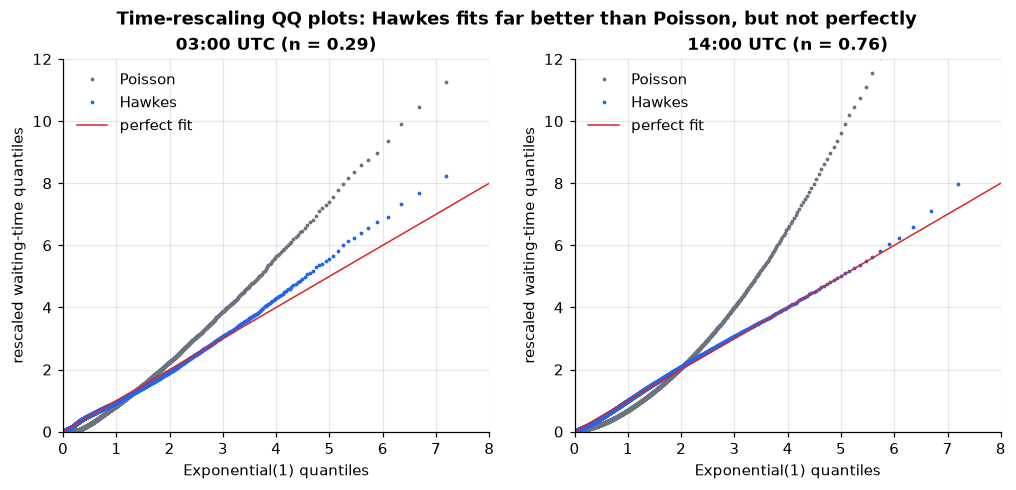

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, hour in zip(axes, [3, 14]):
    tt, f = hours[hour]
    rescaled_hawkes = np.diff(hawkes.compensator(tt, f.mu, f.alpha, f.beta))
    rescaled_poisson = np.diff(tt) * len(tt) / 3600.0
    probs = (np.arange(1, 2001) - 0.5) / 2000
    theo = stats.expon.ppf(probs)
    ax.plot(theo, np.quantile(rescaled_poisson, probs), ".", color=GREY, ms=3, label="Poisson")
    ax.plot(theo, np.quantile(rescaled_hawkes, probs), ".", color=BLUE, ms=3, label="Hawkes")
    ax.plot([0, 8], [0, 8], color=RED, lw=1, label="perfect fit")
    ax.set(xlim=(0, 8), ylim=(0, 12), xlabel="Exponential(1) quantiles", ylabel="rescaled waiting-time quantiles",
           title=f"{hour:02d}:00 UTC (n = {f.branching_ratio:.2f})")
    ax.legend()
    ks = stats.kstest(rescaled_hawkes, "expon")
    print(f"{hour:02d}:00  rescaled gaps: mean {rescaled_hawkes.mean():.3f}, sd {rescaled_hawkes.std():.3f} "
          f"(Exp(1): 1, 1);  KS statistic {ks.statistic:.3f}")
fig.suptitle("Time-rescaling QQ plots: Hawkes fits far better than Poisson, but not perfectly", fontweight="bold")
save(fig, "08_hawkes_qq")

The Poisson model (grey) is wildly off: too many short gaps and too many very long ones. The Hawkes model
(blue) is close to the diagonal for most of the distribution, and the rescaled gaps have mean ≈ 1 as they must.
But it isn't perfect: in the quiet hour the long gaps are too long, and the KS statistics would still reject
it at this sample size. It misses something.

That something is **multiple time scales**. A single exponential kernel has one memory length (here tens
of ms), but markets react at many: microseconds (co-located algos), seconds (slower algos), minutes (humans,
news). Empirically the kernel looks more like a **power law**, and fitting a sum of several exponentials, or
a non-parametric kernel (Bacry & Muzy 2014), fits much better. That's exercise 1.

## Step 4: does a simulated Hawkes process look like the data?

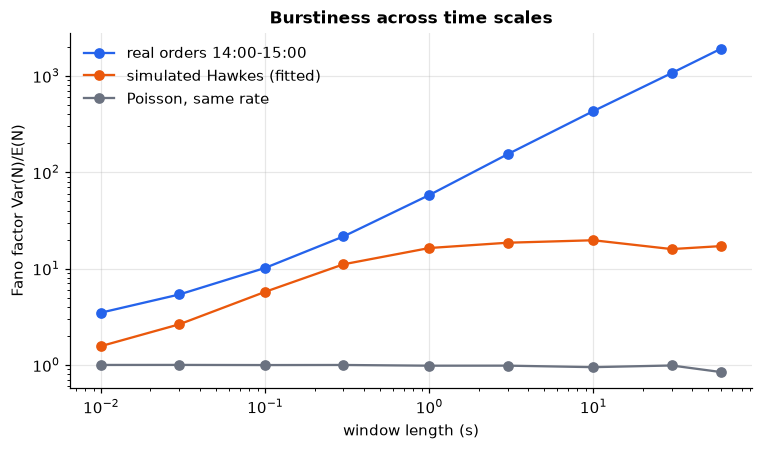

In [5]:
tt, f = hours[14]
sim = hawkes.simulate(f.mu, f.alpha, f.beta, 3600.0, np.random.default_rng(1))
poisson = np.sort(np.random.default_rng(2).uniform(0, 3600, len(tt)))
windows_h = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 60]
fig, ax = plt.subplots()
for times, label, color in [(tt, "real orders 14:00-15:00", BLUE), (sim, "simulated Hawkes (fitted)", ORANGE), (poisson, "Poisson, same rate", GREY)]:
    ax.loglog(windows_h, [fano(times, w, 3600.0) for w in windows_h], "o-", color=color, label=label)
ax.set(xlabel="window length (s)", ylabel="Fano factor Var(N)/E(N)", title="Burstiness across time scales")
ax.legend()
save(fig, "08_fano")

The fitted Hawkes process captures the *shape* of burstiness up to ~0.3 s, the scale of its kernel, though at a
lower level. Then it plateaus around 17, while the real data keeps climbing to ~2,000 at one minute. Again,
that's the missing slow time scales (plus some drift in the baseline rate within the hour). A single fast
kernel can't produce minute-scale clustering. A Poisson process stays flat at 1 throughout.

---
### Interview angle

<details><summary><b>"Orders arrive as a Poisson process at 10 per second. What's the probability of no order in the next 200 ms?"</b></summary>

P(N = 0) = e^(−λt) = e^(−10 × 0.2) = e^(−2) ≈ 13.5%. Then the follow-up: *"Is Poisson realistic?"* No: arrivals
cluster (this chapter). Right after a burst the probability of silence is much lower, and after a long silence
it's higher. A Hawkes model makes the answer depend on the recent history.
</details>

<details><summary><b>"What does a branching ratio of 0.8 mean?"</b></summary>

Each event triggers on average 0.8 direct children, so a cluster started by one exogenous event has on average
1/(1 − 0.8) = 5 events in total, and 80% of all events are endogenous. As n → 1 the system approaches
criticality: small shocks can cascade (flash crashes are sometimes discussed in these terms).
</details>

<details><summary><b>"How would you test whether a point-process model fits?"</b></summary>

Time-rescaling: transform event times with the fitted compensator. Under the model the gaps are i.i.d.
Exp(1). Check with a QQ plot, a KS test, and the autocorrelation of the rescaled gaps (they should be uncorrelated).
</details>

### Try this yourself
1. Extend `micro/hawkes.py` to a kernel that is a sum of two exponentials (one fast, one slow). Does the QQ plot improve?
2. Fit buys and sells as a **bivariate** Hawkes process. Do buys excite sells, or mainly more buys?